# More Exploring with KDE 

Some Notes:
Without weighting, epsilon is just a Euclidean threshold, so it triggers simplex births earlier in dense regions and later in sparse ones. With weighting, epsilon becomes a density-corrected threshold that should trigger births at roughly the same rate everywhere, regardless of local sampling density.

In [27]:
import numpy as np
import matplotlib.pyplot as plt

def sample_circle_half_dense(n, p_dense=0.8, seed=None):
    """
    Sample n points on the unit circle, with p_dense fraction in the dense
    half (theta in [0, pi)) and the remainder in the sparse half ([pi, 2pi)).
    """
    rng = np.random.default_rng(seed)

    # Choose which half each point comes from
    dense_mask = rng.random(n) < p_dense

    theta = np.empty(n)

    # Dense half: [0, pi)
    theta[dense_mask] = rng.uniform(0.0, np.pi, dense_mask.sum())

    # Sparse half: [pi, 2pi)
    theta[~dense_mask] = rng.uniform(np.pi, 2 * np.pi, (~dense_mask).sum())

    X = np.column_stack([np.cos(theta), np.sin(theta)])
    return X, theta

def plot_circle_points(X):
    """Plot 2D points sampled on the unit circle."""
    plt.figure()
    plt.scatter(X[:, 0], X[:, 1], s=10)
    plt.gca().set_aspect('equal', 'box')
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Half-Dense Circle")
    plt.show()

def fhat(X, h=0.15, d_manifold=1):
    """
    Kernel Density Estimate at each sample point using a Gaussian kernel.

    Parameters
    ----------
    X : array, shape (n, m)
        Input points.
    h : float
        Bandwidth parameter.
    d_manifold : int
        Intrinsic dimension of the manifold; used to rescale the KDE.

    Returns
    -------
    fhat : array, shape (n,)
        Estimated density at each point.

    Notes
    -----
    Internally builds an (n, n, m) array via broadcasting, so memory usage
    scales as O(n^2 * m). For large n, consider chunking or scipy.spatial.distance.cdist.
    """
    X = np.asarray(X, dtype=float)
    n, m = X.shape

    # Pairwise differences normalized by h: u_ij = (x_j - x_i) / h
    diff = (X[None, :, :] - X[:, None, :]) / h   # (n, n, m)
    r2 = np.sum(diff ** 2, axis=2)                # (n, n)

    # Gaussian kernel in R^m
    K = np.exp(-0.5 * r2) / ((2 * np.pi) ** (m / 2))  # (n, n)

    # KDE at each x_i
    f = K.sum(axis=1) / (n * (h ** d_manifold))   # (n,)
    return f

def pairwise_dist(X: np.ndarray) -> np.ndarray:
    #Return the (n, n) Euclidean distance matrix for the rows of X.
    diff = X[:, None, :] - X[None, :, :]
    return np.linalg.norm(diff, axis=2)

def weighted_distance_matrix(X, h=0.15, d_manifold=1, sym_rule="min"):
    """
    Build a density-weighted distance matrix D_w such that running standard
    Vietoris–Rips on D_w is equivalent to a density-weighted filtration.

    Parameters
    ----------
    X : array, shape (n, m)
    h : float
        KDE bandwidth.
    d_manifold : int
        Intrinsic dimension used in fhat and the density scaling.
    sym_rule : {'min', 'max', 'mean'}
        How to symmetrize the per-edge density scaling:
        'min'  → divide by max(s_i, s_j)  (conservative)
        'max'  → divide by min(s_i, s_j)  (aggressive)
        'mean' → harmonic mean of s_i, s_j

    Returns
    -------
    D_w : array, shape (n, n)
        Weighted distance matrix.
    f : array, shape (n,)
        KDE values at each point.
    """
    X = np.asarray(X, dtype=float)

    D = pairwise_dist(X)

    f = fhat(X, h=h, d_manifold=d_manifold)
    f = np.maximum(f, 1e-12) # guard against zero density
    f = f / f.mean()            
    s = f ** (1.0 / d_manifold)         # (n,)

    si = s[:, None]
    sj = s[None, :]

    rule = sym_rule.lower().strip()
    if rule == "min":
        scale = np.maximum(si, sj)
    elif rule == "max":
        scale = np.minimum(si, sj)
    elif rule in {"mean", "avg", "average"}:
        scale = (2.0 * si * sj) / (si + sj)
    else:
        raise ValueError("sym_rule must be 'min', 'max', or 'mean'")

    D_w = D * scale
    np.fill_diagonal(D_w, 0.0)
    return D_w, f

def order_vertices_by_eps_neighbors(
    X: np.ndarray,
    epsilon: float,
    D: np.ndarray | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Return a permutation that orders vertices by increasing epsilon-neighbor count.

    Parameters
    ----------
    X : array, shape (n, m)
    epsilon : float
    D : array, shape (n, n), optional
        Precomputed distance matrix. Computed from X if not provided.

    Returns
    -------
    perm : array, shape (n,)
        perm[k] is the OLD index of the vertex placed at position k
        (sorted by increasing neighbor count).
    inv_perm : array, shape (n,)
        inv_perm[i] is the NEW index of old vertex i.
    """
    X = np.asarray(X, dtype=float)
    if D is None:
        D = pairwise_dist(X)

    # Degree in the epsilon-graph (exclude self)
    deg = (D <= epsilon).sum(axis=1) - 1

    # Stable sort so ties preserve original order
    perm = np.argsort(deg, kind="stable")
    inv_perm = np.empty_like(perm)
    inv_perm[perm] = np.arange(len(perm))
    return perm, inv_perm

def Nplus(D: np.ndarray, epsilon: float) -> list[np.ndarray]:
    """
    Precompute N+[i]: the sorted array of neighbors j > i with D[i, j] <= epsilon.

    Restricting to j > i avoids double-counting edges during simplex expansion.
    """
    n = D.shape[0]
    N = []
    for i in range(n):
        js = np.where(D[i, i + 1:] <= epsilon)[0] + (i + 1)
        N.append(js.astype(np.int32))
    return N

def intersect_two_pointer(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    """
    Return the intersection of two sorted 1D integer arrays using two pointers.

    Runs in O(|a| + |b|) time. Both inputs must be sorted in ascending order.
    This enforces that any vertex added to a simplex must be a neighbor of
    every existing vertex in that simplex.
    """
    a = np.asarray(a, dtype=np.int32)
    b = np.asarray(b, dtype=np.int32)
    if a.size == 0 or b.size == 0:
        return np.empty(0, dtype=np.int32)

    i, j = 0, 0
    out = []
    while i < a.size and j < b.size:
        ai, bj = a[i], b[j]
        if ai == bj:
            out.append(ai)
            i += 1
            j += 1
        elif ai < bj:
            # ai < bj: ai can never match bj or anything after it, so advance i
            i += 1
        else:
            # bj < ai: bj can never match anything in a at this position, so advance j
            j += 1

    return np.array(out, dtype=np.int32)

def local_contributions_vr(
    X: np.ndarray,
    epsilon: float,
    max_dim: int | None = None,
    D: np.ndarray | None = None,
) -> list[tuple[float, int]]:
    
    X = np.asarray(X, dtype=float)
    n = X.shape[0]

    if D is None:
        D = pairwise_dist(X)

    # Reorder vertices by increasing epsilon-neighbor count (optimization)
    perm, _ = order_vertices_by_eps_neighbors(X, epsilon, D=D)
    if not np.all(perm == np.arange(n)):
        D = D[np.ix_(perm, perm)]

    N = Nplus(D, epsilon)
    C: list[tuple[float, int]] = []

    def expand(simplex, candidates, f_simplex):
        dim = len(simplex) - 1
        C.append((f_simplex, 1 if dim % 2 == 0 else -1))
        if max_dim is not None and dim >= max_dim:
            return
        for v in candidates:
            v = int(v)
            f_new = max(f_simplex, D[simplex, v].max())
            simplex.append(v)
            expand(simplex, intersect_two_pointer(candidates, N[v]), f_new)
            simplex.pop()

    for i in range(n):
        expand([i], N[i], 0.0)

    C.sort(key=lambda t: t[0])
    return C

def ECC_from_C(
    C: list[tuple[float, int]],
    r_min: float,
    r_max: float,
    num: int = 200,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Compute the Euler Characteristic Curve (ECC) sampled on a uniform grid.

    Parameters
    ----------
    C : list of (filtration_value, sign)
        Output of local_contributions_vr, sorted by filtration value.
    r_min, r_max : float
        Range of the output grid.
    num : int
        Number of grid points.

    Returns
    -------
    r_grid : array, shape (num,)
    ecc : array, shape (num,), dtype int
    """
    if not C:
        r_grid = np.linspace(r_min, r_max, num=num)
        return r_grid, np.zeros_like(r_grid, dtype=int)

    filtration_values = np.array([f for (f, _) in C], dtype=float)
    signs = np.array([s for (_, s) in C], dtype=int)
    prefix_sums = np.cumsum(signs)

    r_grid = np.linspace(r_min, r_max, num=num)

    k = np.searchsorted(filtration_values, r_grid, side="right")
    ecc = np.zeros_like(k, dtype=int)

    mask = k > 0
    ecc[mask] = prefix_sums[k[mask] - 1]

    return r_grid, ecc

def plot_ECC_from_C(
    C: list[tuple[float, int]],
    eps_min: float,
    eps_max: float,
    num: int = 200,
    title: str = "Euler Characteristic Curve (ECC)",
    xlabel: str = "Epsilon",
    ylabel: str = "Euler Characteristic"
) -> tuple[np.ndarray, np.ndarray]:
    """
    Compute and plot the ECC on [eps_min, eps_max]. Returns (r_grid, ecc).

    The ECC is a right-continuous step function of epsilon, plotted with
    plt.step(..., where='post').
    """
    r_grid, ecc = ECC_from_C(C, eps_min, eps_max, num=num)

    plt.figure()
    plt.step(r_grid, ecc, where="post")
    plt.xlim(eps_min, eps_max)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()



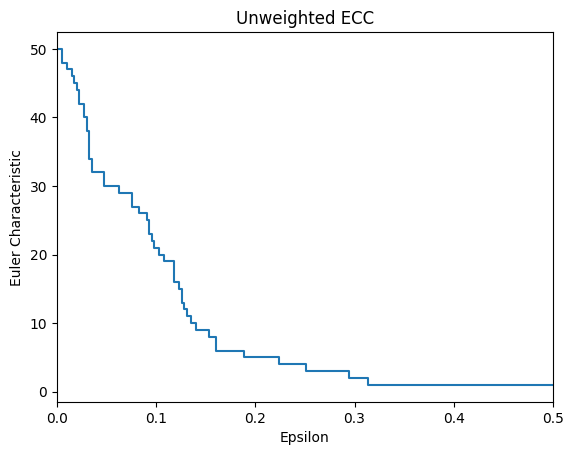

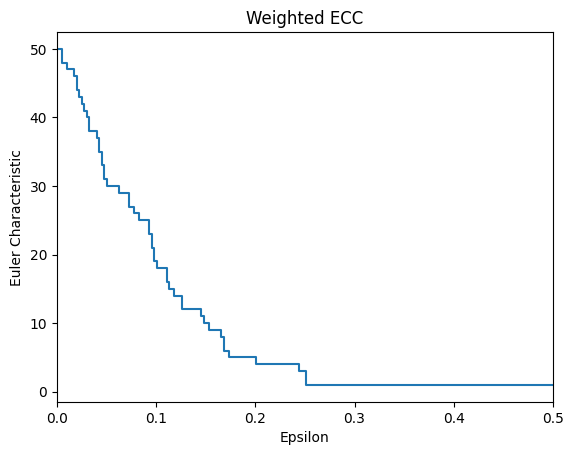

In [30]:
X, theta = sample_circle_half_dense(50, p_dense=0.8, seed=0)
Dw, _ = weighted_distance_matrix(X, h=0.15, d_manifold=1, sym_rule="min")

C_raw = local_contributions_vr(X, epsilon=0.5, max_dim=None)          # unweighted, non-uniform
Cw    = local_contributions_vr(X, epsilon=0.5, max_dim=None, D=Dw)    # weighted, same points

plot_ECC_from_C(C_raw, eps_min=0.0, eps_max=0.5, num = 200, title = "Unweighted ECC" )
plot_ECC_from_C(Cw, eps_min=0.0, eps_max=0.5, num = 200, title = "Weighted ECC" )


# Now we wish to compare using a KDE to the real pdf

In both cases, epsilon is rescaled by $2\pi$ so it represents a fraction of the circle's circumference rather than a raw Euclidean distance. Thus, making the two filtrations geometrically comparable. The KDE version approximates this correction from the data alone; the true-density version applies it exactly, so any difference between the two curves reflects the error in the KDE estimate.

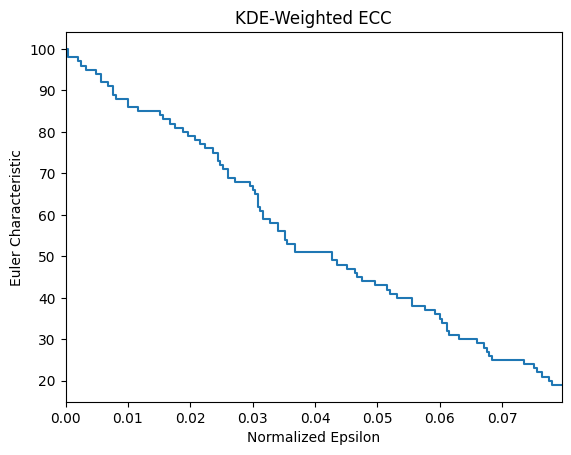

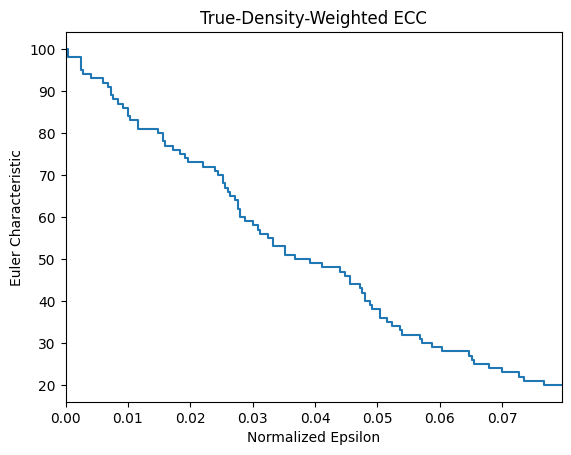

In [37]:
def true_density_half_dense(theta: np.ndarray, p_dense: float = 0.8) -> np.ndarray:
    """
    True PDF of sample_circle_half_dense evaluated at each angle theta.
    Dense half [0, pi):   p_dense / pi
    Sparse half [pi, 2pi): (1 - p_dense) / pi
    """
    f = np.where(theta < np.pi, p_dense / np.pi, (1 - p_dense) / np.pi)
    return f


def weighted_distance_matrix_f(X, f, d_manifold=1, sym_rule="min"):
    """
    Like weighted_distance_matrix, but accepts a precomputed density array f
    instead of estimating it via KDE. f is mean-normalized internally.
    """
    X = np.asarray(X, dtype=float)
    D = pairwise_dist(X)

    f = np.maximum(f, 1e-12)
    f = f / f.mean()
    s = f ** (1.0 / d_manifold)

    si = s[:, None]
    sj = s[None, :]

    rule = sym_rule.lower().strip()
    if rule == "min":
        scale = np.maximum(si, sj)
    elif rule == "max":
        scale = np.minimum(si, sj)
    elif rule in {"mean", "avg", "average"}:
        scale = (2.0 * si * sj) / (si + sj)
    else:
        raise ValueError("sym_rule must be 'min', 'max', or 'mean'")

    D_w = D * scale
    np.fill_diagonal(D_w, 0.0)
    return D_w


# comparison
p_dense = 0.8
X, theta = sample_circle_half_dense(100, p_dense=p_dense, seed=0)

# KDE-weighted
Dw_kde, _ = weighted_distance_matrix(X, h=0.15, d_manifold=1, sym_rule="min")

# True-density-weighted
f_true = true_density_half_dense(theta, p_dense=p_dense)
Dw_true = weighted_distance_matrix_f(X, f_true, d_manifold=1, sym_rule="min")

eps_raw = 0.5
eps = eps_raw / (2 * np.pi)   # rescale so epsilon is in units of fraction-of-circle

C_kde  = local_contributions_vr(X, epsilon=eps, max_dim=None, D=Dw_kde)
C_true = local_contributions_vr(X, epsilon=eps, max_dim=None, D=Dw_true)

plot_ECC_from_C(C_kde,  eps_min=0.0, eps_max=eps, num=200, title="KDE-Weighted ECC", xlabel= "Normalized Epsilon")
plot_ECC_from_C(C_true, eps_min=0.0, eps_max=eps, num=200, title="True-Density-Weighted ECC", xlabel= "Normalized Epsilon")

The two curves are nearly identical in shape! They both start at chi=100 and decline at roughly the same rate to ~20 by $\varepsilon = 0.8$.This means the KDE is doing a good job approximating the true density in this example. The small differences are visible in the step pattern. 